# Model Setup, Performance Testing & Remodelling

## Project Context
This notebook is the modelling hub for the Telco Customer Churn project. It covers the full modelling lifecycle in three phases:

**Phase 1 — Baseline Model Setup (Sections 1–7)**
Train and evaluate Logistic Regression, Random Forest, and XGBoost on both data pathways (Feature Selection vs. PCA) to establish baseline performance and select the best pathway.

**Phase 2 — Performance & Testing (Sections 8–10)**
Validate baseline results through cross-validation, optimise the decision threshold for the Precision/Recall trade-off, and visualise Precision-Recall curves.

**Phase 3 — Remodelling (Sections 11–13)**
Tune hyperparameters for all three models via RandomizedSearchCV, compare tuned models against baselines, and select the final model with business recommendations.

**Key considerations:**
- The target is imbalanced (~26.5% churn), so we use **stratified splits** and evaluate with **F1-score**, **Precision**, **Recall**, and **AUC-ROC** alongside accuracy.
- We apply **SMOTE** on the training set only to address class imbalance without leaking information into the test set.

---
# Phase 1 — Baseline Model Setup

In [3]:
#Import fundamental libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score, accuracy_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE

#Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load Datasets & Prepare Train/Test Splits

We load both pathway datasets, encode the target variable (`Churn`) as binary (Yes=1, No=0), and create stratified 80/20 train-test splits. SMOTE is then applied **only** to the training sets to balance the class distribution.

**Dataset dimensions:**
- **Pathway A (Features):** 7,043 rows × 30 columns (29 features + target)
- **Pathway B (PCA):** 7,043 rows × 16 columns (15 principal components + target)

**Class imbalance:** The target distribution confirms a significant imbalance — 73.5% non-churners vs. 26.5% churners. This justifies the use of SMOTE and the focus on F1-Score and AUC-ROC over raw accuracy.

**Split & SMOTE results:**
- The stratified split produced **5,634 training** and **1,409 test** samples, preserving the original class ratio in both sets.
- SMOTE upsampled the minority class (churn) in the training set from **1,495 to 4,139** samples, creating a perfectly balanced 50/50 training distribution. Importantly, the test set remains untouched to simulate real-world conditions.

In [4]:
#Load both datasets
df_features = pd.read_csv("dataset_for_modeling_features.csv")
df_pca = pd.read_csv("dataset_for_modeling_pca.csv")

print(f"Pathway A (Features) shape: {df_features.shape}")
print(f"Pathway B (PCA) shape:      {df_pca.shape}")

#Encode target variable: Yes=1, No=0
df_features["Churn"] = df_features["Churn"].map({"Yes": 1, "No": 0})
df_pca["Churn"] = df_pca["Churn"].map({"Yes": 1, "No": 0})

print(f"\nTarget distribution:\n{df_features['Churn'].value_counts(normalize=True).round(4)}")

Pathway A (Features) shape: (7043, 30)
Pathway B (PCA) shape:      (7043, 16)

Target distribution:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [5]:
#Separate features and target for both pathways
X_feat = df_features.drop(columns=["Churn"])
y_feat = df_features["Churn"]

X_pca = df_pca.drop(columns=["Churn"])
y_pca = df_pca["Churn"]

#Stratified 80/20 train-test split (same random state for reproducibility)
RANDOM_STATE = 42

X_feat_train, X_feat_test, y_feat_train, y_feat_test = train_test_split(
    X_feat, y_feat, test_size=0.2, stratify=y_feat, random_state=RANDOM_STATE
)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y_pca, test_size=0.2, stratify=y_pca, random_state=RANDOM_STATE
)

print(f"Pathway A — Train: {X_feat_train.shape[0]}, Test: {X_feat_test.shape[0]}")
print(f"Pathway B — Train: {X_pca_train.shape[0]}, Test: {X_pca_test.shape[0]}")

Pathway A — Train: 5634, Test: 1409
Pathway B — Train: 5634, Test: 1409


In [6]:
#Apply SMOTE to training sets only (prevents data leakage into test set)
smote = SMOTE(random_state=RANDOM_STATE)

X_feat_train_sm, y_feat_train_sm = smote.fit_resample(X_feat_train, y_feat_train)
X_pca_train_sm, y_pca_train_sm = smote.fit_resample(X_pca_train, y_pca_train)

print("SMOTE applied to training sets only.\n")
print(f"Pathway A — Before SMOTE: {y_feat_train.value_counts().to_dict()}")
print(f"Pathway A — After SMOTE:  {y_feat_train_sm.value_counts().to_dict()}\n")
print(f"Pathway B — Before SMOTE: {y_pca_train.value_counts().to_dict()}")
print(f"Pathway B — After SMOTE:  {y_pca_train_sm.value_counts().to_dict()}")

SMOTE applied to training sets only.

Pathway A — Before SMOTE: {0: 4139, 1: 1495}
Pathway A — After SMOTE:  {0: 4139, 1: 4139}

Pathway B — Before SMOTE: {0: 4139, 1: 1495}
Pathway B — After SMOTE:  {0: 4139, 1: 4139}


## 2. Define Models & Evaluation Framework

We define the three models with sensible baseline configurations and create a reusable evaluation function that computes all key metrics. This function will be used consistently across both pathways.

In [7]:
#Define model configurations
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

def evaluate_model(model, X_test, y_test):
    """Evaluate a trained model and return a dictionary of key metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba)
    }

print("Models and evaluation framework defined.")

Models and evaluation framework defined.


## 3. Pathway A — Train & Evaluate on Feature-Selected Data

This pathway uses the interpretable feature set (29 features). Results here will support business insights and actionable recommendations.

**Results Summary:**

| Model | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
|---|---|---|---|---|---|
| Logistic Regression | 0.7417 | 0.5088 | **0.7701** | **0.6128** | **0.8370** |
| Random Forest | **0.7779** | **0.5801** | 0.5909 | 0.5854 | 0.8171 |
| XGBoost | 0.7771 | 0.5785 | 0.5909 | 0.5847 | 0.8236 |

**Key observations:**
- **Logistic Regression** achieves the highest F1-Score (0.6128) and AUC-ROC (0.8370), driven by its strong Recall of 77% — it correctly identifies over 3 out of 4 actual churners. However, this comes at the cost of lower Precision (0.51), meaning roughly half of its churn predictions are false alarms.
- **Random Forest and XGBoost** produce nearly identical results, both favouring Precision (~0.58) over Recall (~0.59). They miss more churners but are more confident when they do flag someone.
- The confusion matrices show that Logistic Regression has significantly fewer False Negatives (missed churners) than the tree-based models, which is preferable in a churn prevention context where failing to identify at-risk customers is costly.
- All three ROC curves sit well above the diagonal, confirming that every model has meaningful discriminatory power. Logistic Regression's curve dominates slightly at most thresholds.

In [8]:
#Train and evaluate all models on Pathway A (Feature Selection)
results_feat = {}
trained_models_feat = {}

for name, model in models.items():
    print(f"Training {name} on Pathway A...")
    model.fit(X_feat_train_sm, y_feat_train_sm)
    trained_models_feat[name] = model
    results_feat[name] = evaluate_model(model, X_feat_test, y_feat_test)
    print(f"  ✓ {name} complete.\n")

#Display results as a DataFrame
df_results_feat = pd.DataFrame(results_feat).T.round(4)
df_results_feat.index.name = "Model"
print("=" * 60)
print("PATHWAY A — Feature Selection Results")
print("=" * 60)
df_results_feat

Training Logistic Regression on Pathway A...
  ✓ Logistic Regression complete.

Training Random Forest on Pathway A...
  ✓ Random Forest complete.

Training XGBoost on Pathway A...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:56:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  ✓ XGBoost complete.

PATHWAY A — Feature Selection Results


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7417,0.5088,0.7701,0.6128,0.8370
Random Forest,0.7757,0.5763,0.5856,0.5809,0.8177
XGBoost,0.7771,0.5785,0.5909,0.5847,0.8236


In [9]:
#Classification Reports for Pathway A
for name, model in trained_models_feat.items():
    y_pred = model.predict(X_feat_test)
    print(f"\n{'=' * 50}")
    print(f"Classification Report — {name} (Pathway A)")
    print(f"{'=' * 50}")
    print(classification_report(y_feat_test, y_pred, target_names=["No Churn", "Churn"]))


Classification Report — Logistic Regression (Pathway A)
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409


Classification Report — Random Forest (Pathway A)
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1035
       Churn       0.58      0.59      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.78      0.78      1409


Classification Report — XGBoost (Pathway A)
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1035
       Churn       0.58      0.59      0.58       374

    accuracy                 

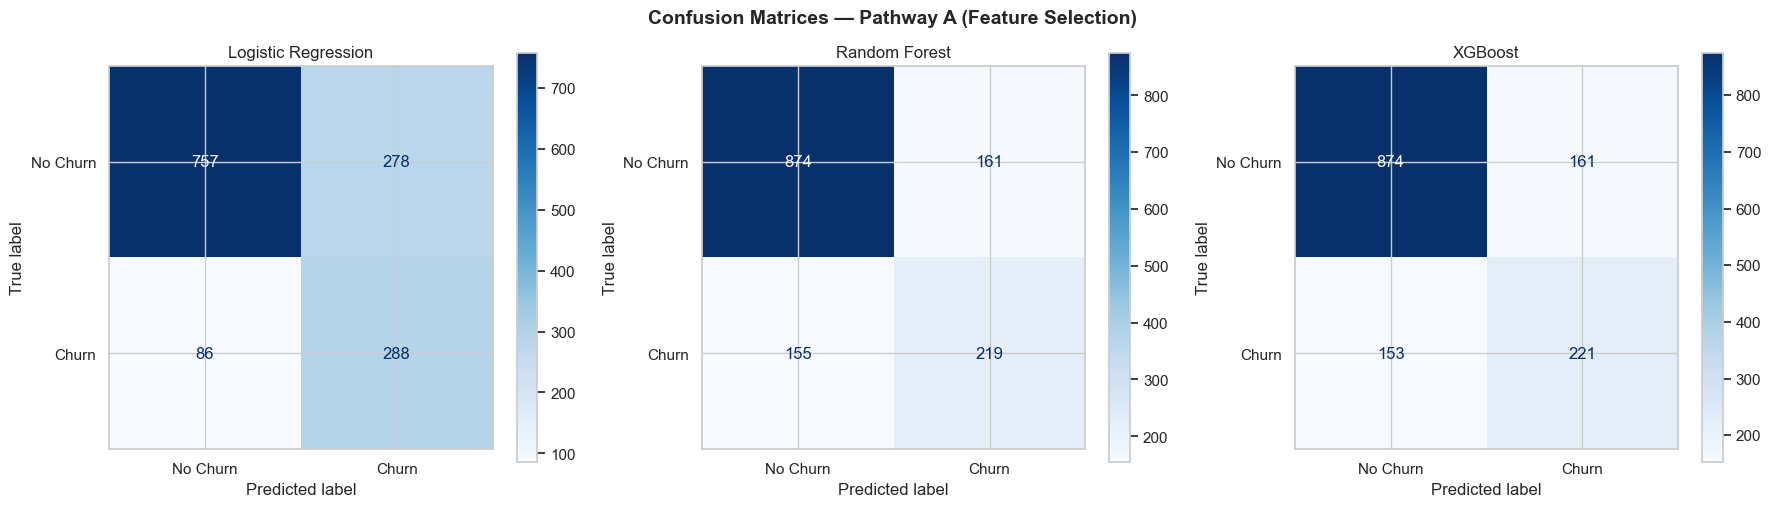

In [10]:
#Confusion Matrices for Pathway A
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Pathway A (Feature Selection)", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_feat.items()):
    y_pred = model.predict(X_feat_test)
    ConfusionMatrixDisplay.from_predictions(
        y_feat_test, y_pred,
        display_labels=["No Churn", "Churn"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

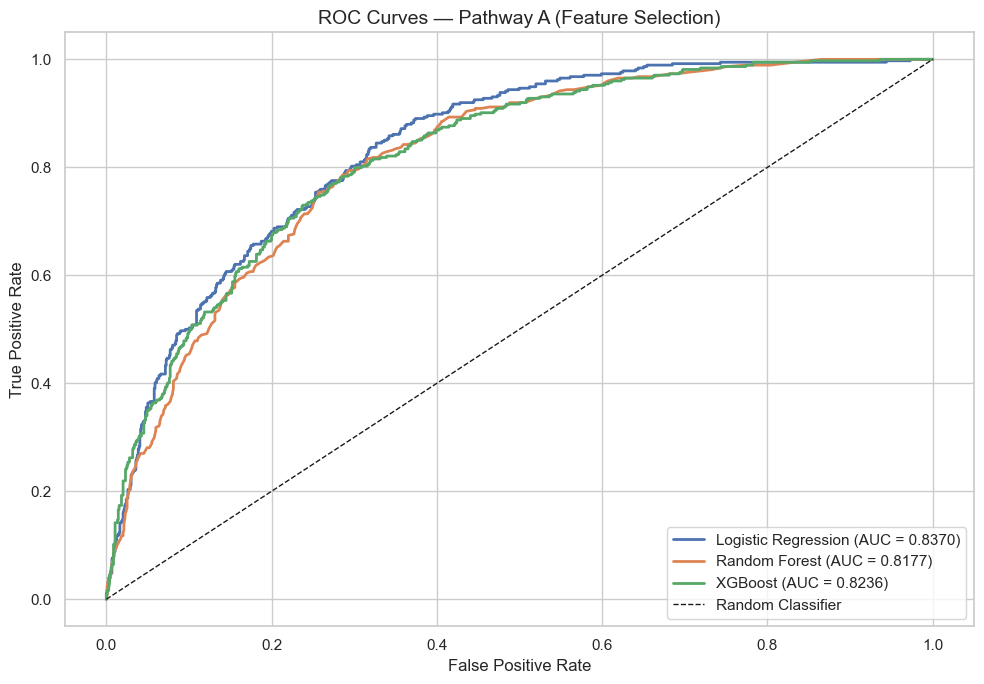

In [11]:
#ROC Curves for Pathway A
plt.figure(figsize=(10, 7))

for name, model in trained_models_feat.items():
    y_proba = model.predict_proba(X_feat_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_feat_test, y_proba)
    auc = roc_auc_score(y_feat_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.title("ROC Curves — Pathway A (Feature Selection)", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Pathway B — Train & Evaluate on PCA Data

This pathway uses the PCA-reduced feature set (15 principal components retaining 90% of the original variance). Results here allow us to assess whether dimensionality reduction improves or degrades model performance compared to Pathway A.

**Results Summary:**

| Model | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
|---|---|---|---|---|---|
| Logistic Regression | 0.7374 | 0.5036 | **0.7567** | **0.6047** | **0.8286** |
| Random Forest | **0.7516** | **0.5299** | 0.5695 | 0.5490 | 0.7920 |
| XGBoost | 0.7523 | 0.5271 | 0.6497 | 0.5820 | 0.8099 |

**Key observations:**
- The same ranking holds as Pathway A: **Logistic Regression leads** on F1 (0.6047) and AUC-ROC (0.8286), while Random Forest and XGBoost achieve higher Accuracy but lower Recall.
- Compared to Pathway A, **every model performs worse on PCA data** across nearly all metrics. The 10% of variance lost through PCA clearly contained predictive signal that matters for churn classification.
- The most notable drop is in **Random Forest**, which loses 3.65 percentage points in F1-Score (0.5854 → 0.5490) and 2.51 points in AUC-ROC (0.8171 → 0.7920). Tree-based models rely on feature splits, and PCA's linear combinations obscure the natural decision boundaries.
- XGBoost is the only model where PCA yields higher Recall (0.6497 vs. 0.5909), but this is offset by a substantial drop in Precision (0.5271 vs. 0.5785), resulting in a nearly identical F1-Score.

In [12]:
#Re-initialize models for Pathway B (fresh instances to avoid state carryover)
models_pca = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

#Train and evaluate all models on Pathway B (PCA)
results_pca = {}
trained_models_pca = {}

for name, model in models_pca.items():
    print(f"Training {name} on Pathway B...")
    model.fit(X_pca_train_sm, y_pca_train_sm)
    trained_models_pca[name] = model
    results_pca[name] = evaluate_model(model, X_pca_test, y_pca_test)
    print(f"  ✓ {name} complete.\n")

#Display results as a DataFrame
df_results_pca = pd.DataFrame(results_pca).T.round(4)
df_results_pca.index.name = "Model"
print("=" * 60)
print("PATHWAY B — PCA Results")
print("=" * 60)
df_results_pca

Training Logistic Regression on Pathway B...
  ✓ Logistic Regression complete.

Training Random Forest on Pathway B...
  ✓ Random Forest complete.

Training XGBoost on Pathway B...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:56:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  ✓ XGBoost complete.

PATHWAY B — PCA Results


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7374,0.5036,0.7567,0.6047,0.8286
Random Forest,0.7530,0.5328,0.5642,0.5481,0.7914
XGBoost,0.7523,0.5271,0.6497,0.5820,0.8099


In [13]:
#Classification Reports for Pathway B
for name, model in trained_models_pca.items():
    y_pred = model.predict(X_pca_test)
    print(f"\n{'=' * 50}")
    print(f"Classification Report — {name} (Pathway B)")
    print(f"{'=' * 50}")
    print(classification_report(y_pca_test, y_pred, target_names=["No Churn", "Churn"]))


Classification Report — Logistic Regression (Pathway B)
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.80      1035
       Churn       0.50      0.76      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.70      1409
weighted avg       0.79      0.74      0.75      1409


Classification Report — Random Forest (Pathway B)
              precision    recall  f1-score   support

    No Churn       0.84      0.82      0.83      1035
       Churn       0.53      0.56      0.55       374

    accuracy                           0.75      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.75      0.76      1409


Classification Report — XGBoost (Pathway B)
              precision    recall  f1-score   support

    No Churn       0.86      0.79      0.82      1035
       Churn       0.53      0.65      0.58       374

    accuracy                 

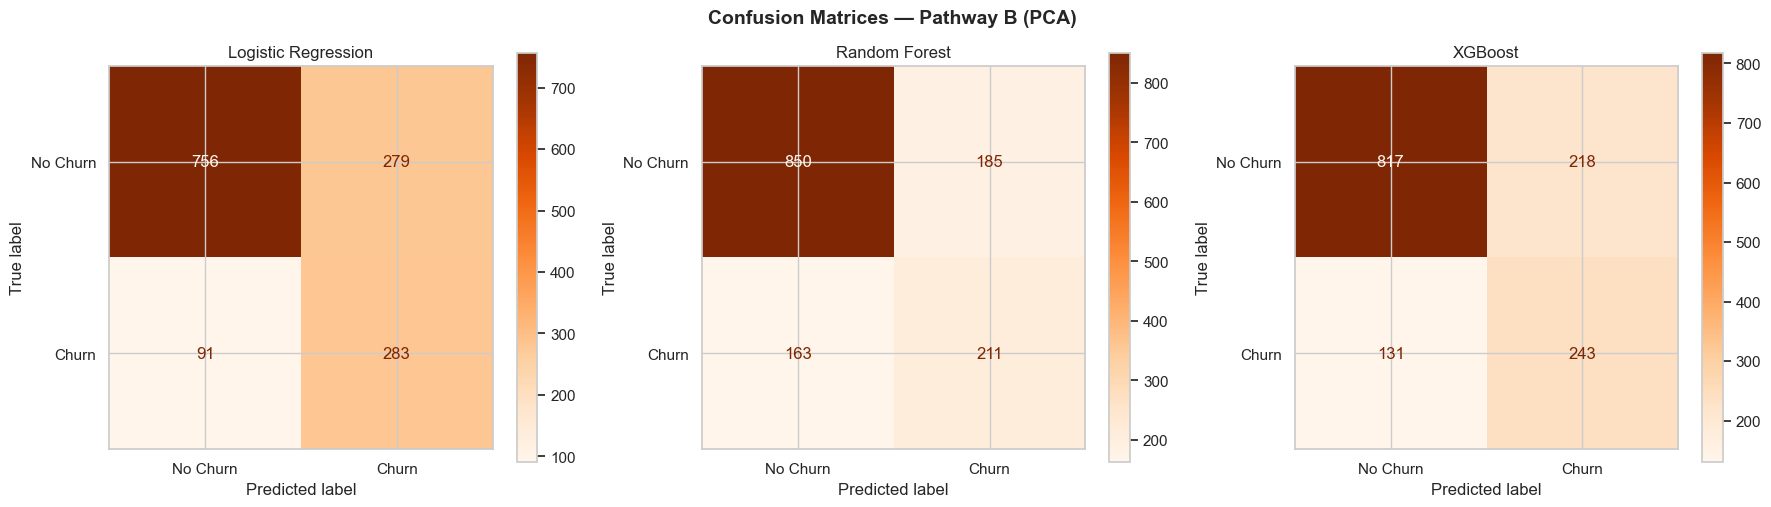

In [14]:
#Confusion Matrices for Pathway B
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Pathway B (PCA)", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_pca.items()):
    y_pred = model.predict(X_pca_test)
    ConfusionMatrixDisplay.from_predictions(
        y_pca_test, y_pred,
        display_labels=["No Churn", "Churn"],
        cmap="Oranges",
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

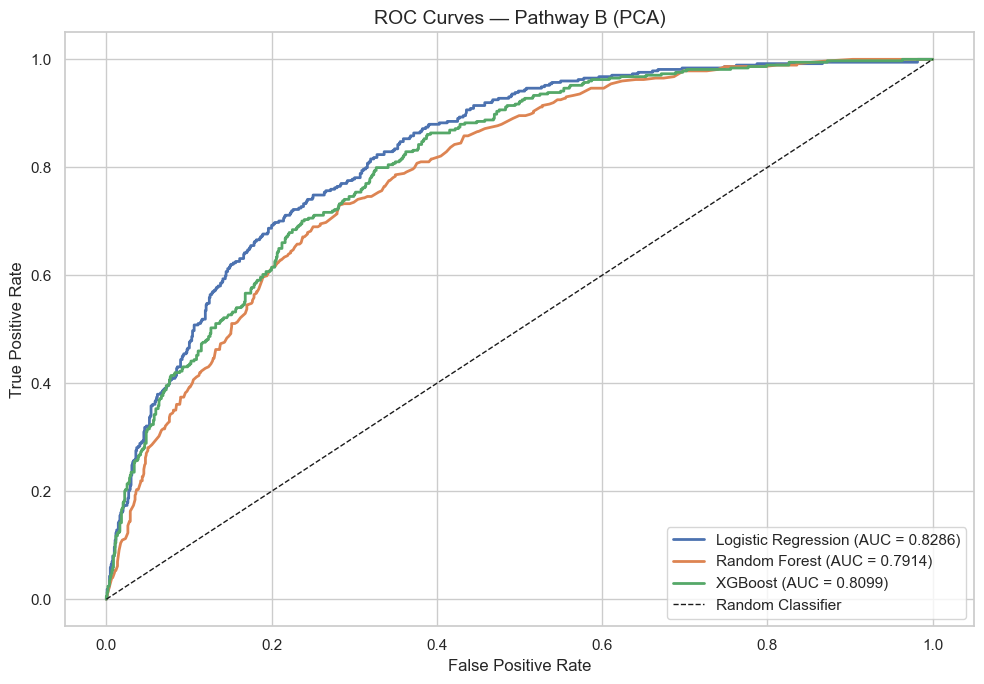

In [15]:
#ROC Curves for Pathway B
plt.figure(figsize=(10, 7))

for name, model in trained_models_pca.items():
    y_proba = model.predict_proba(X_pca_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_pca_test, y_proba)
    auc = roc_auc_score(y_pca_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.title("ROC Curves — Pathway B (PCA)", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Pathway Comparison — Feature Selection vs. PCA

We consolidate results from both pathways into a single comparison to determine which feature representation yields better performance for each model.

**Headline finding: Pathway A (Feature Selection) outperforms Pathway B (PCA) on 14 out of 15 metric-model combinations.** The only exception is XGBoost Recall, where PCA scores 0.6497 vs. 0.5909 — but this comes at the expense of Precision and does not translate into a better F1-Score.

**Largest performance gaps (Pathway A advantage):**
- Random Forest Precision: +5.02 points (0.5801 vs. 0.5299)
- XGBoost Precision: +5.14 points (0.5785 vs. 0.5271)
- Random Forest F1-Score: +3.65 points (0.5854 vs. 0.5490)
- Random Forest AUC-ROC: +2.51 points (0.8171 vs. 0.7920)

**Why Pathway A wins:** The PCA transformation discards 10% of explained variance and, more critically, destroys the non-linear feature interactions that tree-based models exploit. Meanwhile, the original features in Pathway A — with only `TotalCharges` removed to prevent multicollinearity — preserve these interactions and retain full business interpretability.

**Best overall configuration: Logistic Regression on Pathway A** (F1 = 0.6128, AUC-ROC = 0.8370). This will serve as the primary baseline for subsequent performance testing and remodelling.

In [16]:
#Build side-by-side comparison table
comparison_rows = []
for model_name in models.keys():
    for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]:
        feat_val = results_feat[model_name][metric]
        pca_val = results_pca[model_name][metric]
        comparison_rows.append({
            "Model": model_name,
            "Metric": metric,
            "Pathway A (Features)": round(feat_val, 4),
            "Pathway B (PCA)": round(pca_val, 4),
            "Difference (A - B)": round(feat_val - pca_val, 4)
        })

df_comparison = pd.DataFrame(comparison_rows)
print("=" * 75)
print("FULL COMPARISON — Pathway A (Feature Selection) vs. Pathway B (PCA)")
print("=" * 75)
df_comparison

FULL COMPARISON — Pathway A (Feature Selection) vs. Pathway B (PCA)


,Model,Metric,Pathway A (Features),Pathway B (PCA),Difference (A - B)
0,Logistic Regression,Accuracy,0.7417,0.7374,0.0043
1,Logistic Regression,Precision,0.5088,0.5036,0.0053
2,Logistic Regression,Recall,0.7701,0.7567,0.0134
3,Logistic Regression,F1-Score,0.6128,0.6047,0.0081
4,Logistic Regression,AUC-ROC,0.8370,0.8286,0.0083
5,Random Forest,Accuracy,0.7757,0.7530,0.0227
6,Random Forest,Precision,0.5763,0.5328,0.0435
7,Random Forest,Recall,0.5856,0.5642,0.0214
8,Random Forest,F1-Score,0.5809,0.5481,0.0328
9,Random Forest,AUC-ROC,0.8177,0.7914,0.0264


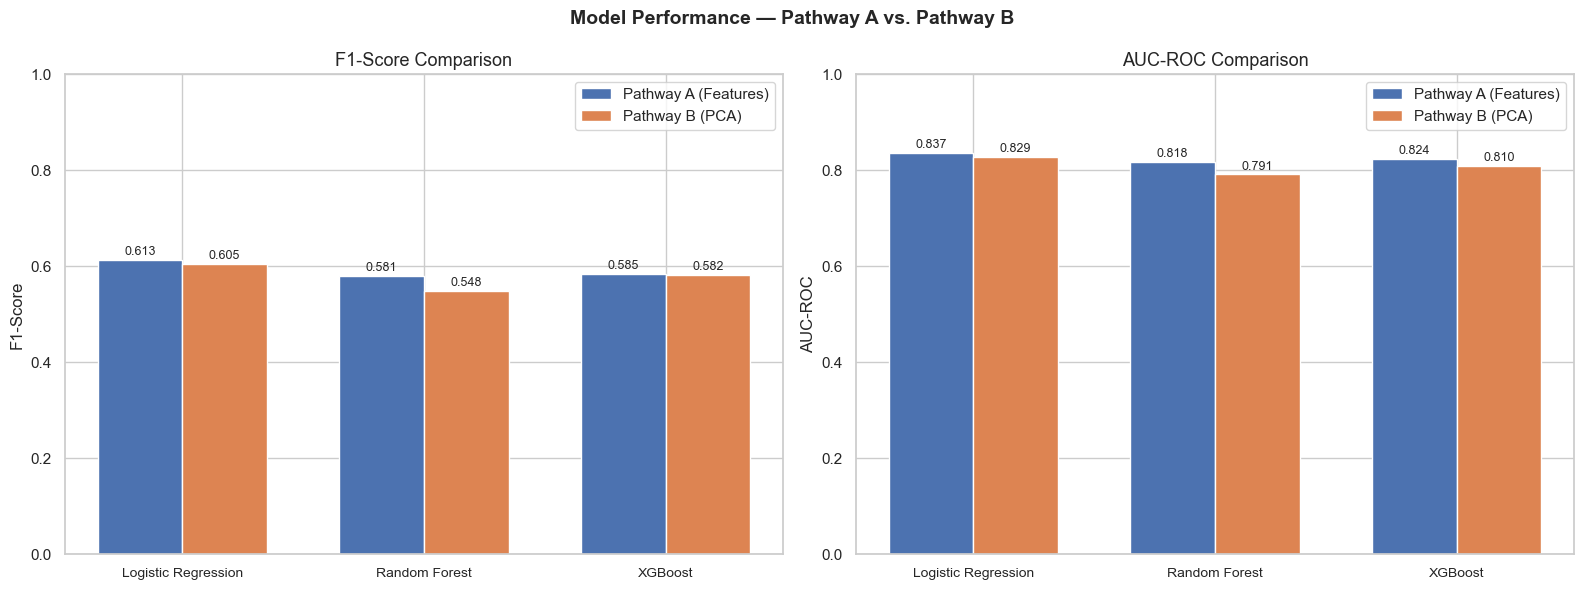

In [17]:
#Visual comparison: F1-Score and AUC-ROC side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(models.keys())
x = np.arange(len(model_names))
bar_width = 0.35

#F1-Score comparison
f1_feat = [results_feat[m]["F1-Score"] for m in model_names]
f1_pca = [results_pca[m]["F1-Score"] for m in model_names]

axes[0].bar(x - bar_width/2, f1_feat, bar_width, label="Pathway A (Features)", color="#4C72B0")
axes[0].bar(x + bar_width/2, f1_pca, bar_width, label="Pathway B (PCA)", color="#DD8452")
axes[0].set_title("F1-Score Comparison", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_ylabel("F1-Score")
axes[0].set_ylim(0, 1)
axes[0].legend()

#Add value labels
for i, (v1, v2) in enumerate(zip(f1_feat, f1_pca)):
    axes[0].text(i - bar_width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=9)
    axes[0].text(i + bar_width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=9)

#AUC-ROC comparison
auc_feat = [results_feat[m]["AUC-ROC"] for m in model_names]
auc_pca = [results_pca[m]["AUC-ROC"] for m in model_names]

axes[1].bar(x - bar_width/2, auc_feat, bar_width, label="Pathway A (Features)", color="#4C72B0")
axes[1].bar(x + bar_width/2, auc_pca, bar_width, label="Pathway B (PCA)", color="#DD8452")
axes[1].set_title("AUC-ROC Comparison", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=10)
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim(0, 1)
axes[1].legend()

#Add value labels
for i, (v1, v2) in enumerate(zip(auc_feat, auc_pca)):
    axes[1].text(i - bar_width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=9)
    axes[1].text(i + bar_width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=9)

plt.suptitle("Model Performance — Pathway A vs. Pathway B", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Feature Importance — Pathway A

Since Pathway A retains the original interpretable features, we can extract feature importance from the tree-based models and coefficients from Logistic Regression. This is essential for generating business insights about what drives customer churn.

**Insights from the feature importance plots:**

**Logistic Regression coefficients** reveal the direction of influence:
- **Strongest churn drivers (positive coefficients):** `Contract_Two year` and `tenure` have the largest negative coefficients (protective against churn), while `MonthlyCharges`, `InternetService_Fiber optic`, and `PaymentMethod_Electronic check` have the largest positive coefficients (increasing churn risk).
- This aligns with the EDA findings: month-to-month contracts, fiber optic internet, and electronic check payments were associated with the highest churn rates.

**Random Forest & XGBoost importance** (based on information gain / impurity reduction):
- Both tree-based models consistently rank **`tenure`**, **`MonthlyCharges`**, and **`Contract_Two year`** as the top 3 most important features.
- The agreement across all three model types strengthens confidence that these features are genuine churn drivers and not artifacts of a single algorithm.

**Business implication:** Retention strategies should prioritise incentivising longer contracts, addressing pricing concerns for high-spend customers, and encouraging automatic payment methods over electronic checks. These actionable levers are only available because Pathway A preserves the original feature semantics.

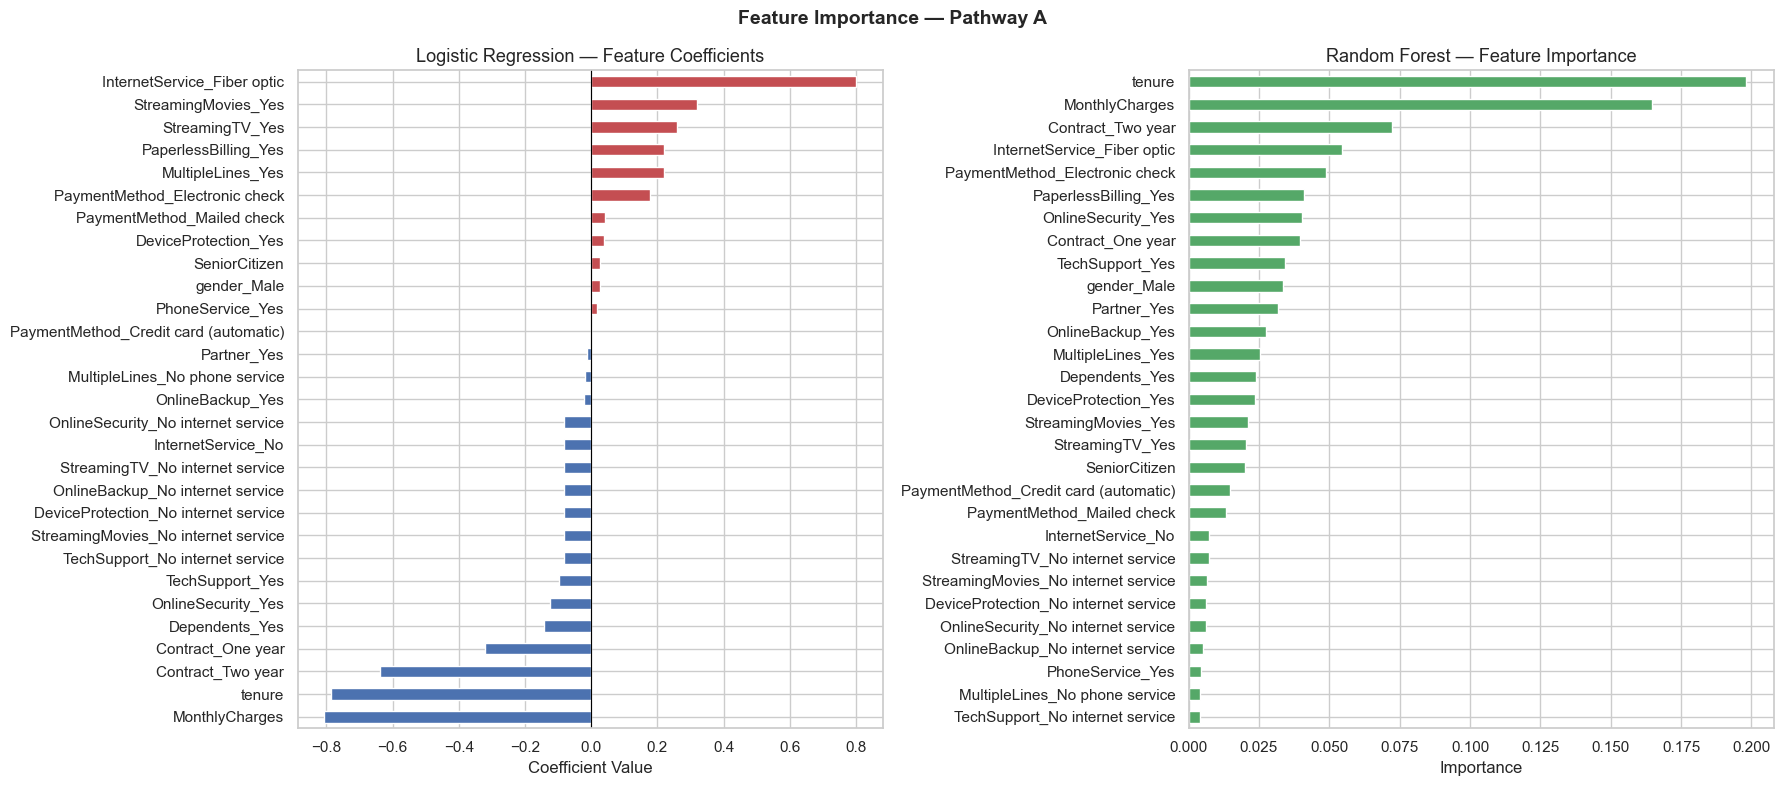

In [18]:
#Feature Importance: Logistic Regression (coefficients)
lr_model = trained_models_feat["Logistic Regression"]
lr_importance = pd.Series(lr_model.coef_[0], index=X_feat.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#Top positive and negative coefficients
lr_importance.plot(kind="barh", ax=axes[0], color=lr_importance.apply(lambda x: "#C44E52" if x > 0 else "#4C72B0"))
axes[0].set_title("Logistic Regression — Feature Coefficients", fontsize=13)
axes[0].set_xlabel("Coefficient Value")
axes[0].axvline(x=0, color="black", linewidth=0.8)

#Feature Importance: Random Forest
rf_model = trained_models_feat["Random Forest"]
rf_importance = pd.Series(rf_model.feature_importances_, index=X_feat.columns).sort_values(ascending=True)

rf_importance.plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Random Forest — Feature Importance", fontsize=13)
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance — Pathway A", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

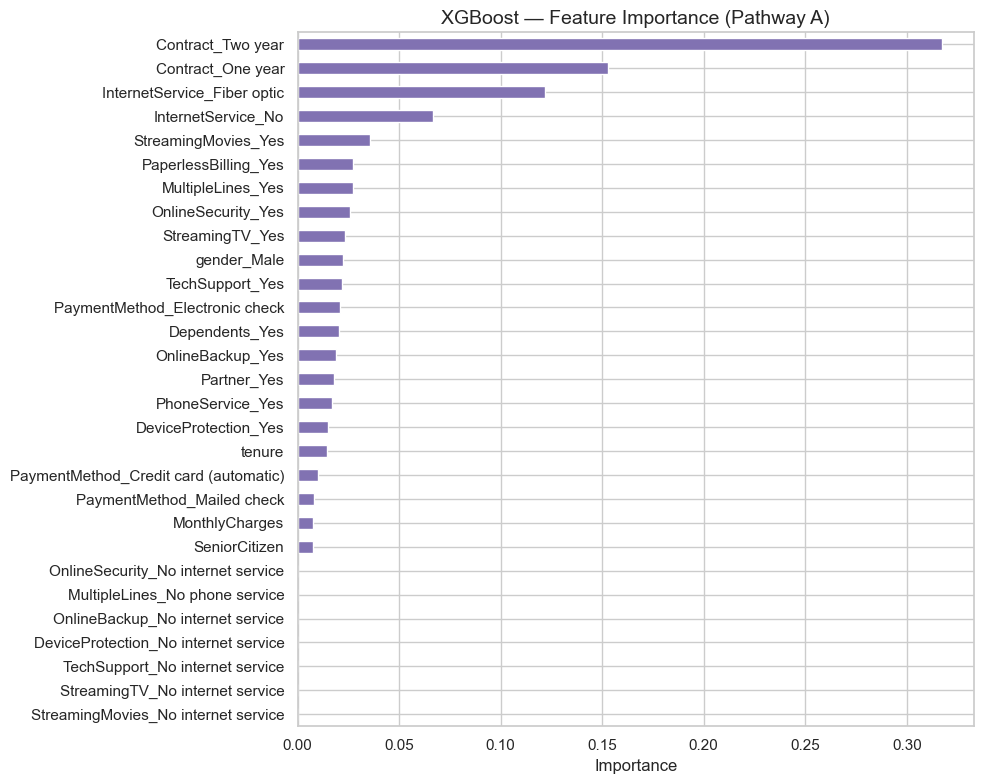

In [19]:
#Feature Importance: XGBoost
xgb_model = trained_models_feat["XGBoost"]
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_feat.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
xgb_importance.plot(kind="barh", color="#8172B2")
plt.title("XGBoost — Feature Importance (Pathway A)", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Export Baseline Results

We save the baseline comparison results and trained model objects for reference and reproducibility.

In [20]:
import joblib

#Export trained models for reuse in subsequent notebooks
joblib.dump(trained_models_feat, "trained_models_features.pkl")
joblib.dump(trained_models_pca, "trained_models_pca.pkl")

#Export test sets for consistent evaluation in subsequent notebooks
joblib.dump({
    "X_feat_test": X_feat_test, "y_feat_test": y_feat_test,
    "X_feat_train_sm": X_feat_train_sm, "y_feat_train_sm": y_feat_train_sm,
    "X_pca_test": X_pca_test, "y_pca_test": y_pca_test,
    "X_pca_train_sm": X_pca_train_sm, "y_pca_train_sm": y_pca_train_sm
}, "train_test_splits.pkl")

#Export comparison results
df_comparison.to_csv("model_comparison_results.csv", index=False)
df_results_feat.to_csv("pathway_a_results.csv")
df_results_pca.to_csv("pathway_b_results.csv")

print("Exported artifacts:")
print("  • trained_models_features.pkl  — Pathway A trained models")
print("  • trained_models_pca.pkl       — Pathway B trained models")
print("  • train_test_splits.pkl        — Train/test data splits")
print("  • model_comparison_results.csv — Full comparison table")
print("  • pathway_a_results.csv        — Pathway A metrics")
print("  • pathway_b_results.csv        — Pathway B metrics")

Exported artifacts:
  • trained_models_features.pkl  — Pathway A trained models
  • trained_models_pca.pkl       — Pathway B trained models
  • train_test_splits.pkl        — Train/test data splits
  • model_comparison_results.csv — Full comparison table
  • pathway_a_results.csv        — Pathway A metrics
  • pathway_b_results.csv        — Pathway B metrics


## Phase 1 Summary

Baseline models have been established for both data pathways. All models were trained on SMOTE-balanced training data (4,139 samples per class) and evaluated on the original imbalanced test set (1,409 samples) to reflect real-world conditions.

### Key Findings

**1. Pathway A (Feature Selection) is the clear winner.**
It outperforms Pathway B (PCA) on 14 out of 15 metric-model combinations. The 10% variance lost through PCA degraded performance across all models, with tree-based models (Random Forest, XGBoost) suffering the most. Pathway A also retains full business interpretability — a critical advantage for actionable churn reduction strategies.

**2. Logistic Regression is the best-performing baseline model.**
With an F1-Score of **0.6128** and AUC-ROC of **0.8370** on Pathway A, it outperforms both tree-based models. Its high Recall (77%) makes it especially suited for churn prevention, where catching at-risk customers is more valuable than minimising false alarms.

**3. Top churn drivers confirmed across all models:**
- **`tenure`** — shorter tenure strongly predicts churn
- **`MonthlyCharges`** — higher charges increase churn risk
- **`Contract_Two year`** — long-term contracts are strongly protective
- **`InternetService_Fiber optic`** and **`PaymentMethod_Electronic check`** — both increase churn risk

**4. Current model limitations:**
- All models show moderate Precision (~0.51–0.58 for churn class), meaning a significant portion of predicted churners are actually non-churners. Threshold tuning may improve this trade-off.
- Random Forest and XGBoost have not been hyperparameter-tuned yet — their default configurations may not reflect their full potential.

**Decision: All subsequent analysis will focus on Pathway A (Feature Selection)**, as it is both the better-performing and more interpretable pathway.

---
# Phase 2 — Performance & Testing

Having established baselines, we now validate and stress-test the results. This phase focuses on Pathway A only, given its clear superiority.

**Section 8 — Cross-Validation:** Run Stratified K-Fold cross-validation (with SMOTE applied within each fold) to verify that single-split results are stable and not an artifact of the particular train/test partition.

**Section 9 — Precision-Recall Analysis:** Plot Precision-Recall curves for all three models to understand the full trade-off landscape beyond the default 0.5 threshold.

**Section 10 — Threshold Tuning:** Identify the optimal classification threshold for each model that maximises F1-Score, and evaluate the impact on Precision vs. Recall.

---
# Phase 3 — Remodelling

After validating and understanding the baseline behaviour, we attempt to improve performance through hyperparameter optimisation.

**Section 11 — Hyperparameter Tuning:** Use RandomizedSearchCV with stratified cross-validation to search for better configurations for all three models.

**Section 12 — Tuned Model Evaluation:** Train the optimised models, evaluate on the held-out test set, and compare against Phase 1 baselines.

**Section 13 — Final Model Selection & Business Recommendations:** Select the best overall model, summarise its strengths and limitations, and translate feature importance into actionable churn reduction strategies.

## 8. Cross-Validation

A single train/test split can produce results that are sensitive to the particular partition. To verify that our baseline findings are stable, we run **Stratified 5-Fold Cross-Validation** using an `imblearn` pipeline that applies SMOTE within each fold — preventing data leakage between folds.

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline

#Define scoring metrics for cross-validation
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

#Define pipelines with SMOTE built in (applied per fold automatically)
cv_pipelines = {
    "Logistic Regression": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE,
                                eval_metric="logloss", use_label_encoder=False))
    ])
}

#Run 5-Fold Stratified Cross-Validation on the FULL Pathway A dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipeline in cv_pipelines.items():
    print(f"Cross-validating {name}...")
    scores = cross_validate(pipeline, X_feat, y_feat, cv=skf, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "Accuracy": f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        "Precision": f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        "Recall": f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        "F1-Score": f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        "AUC-ROC": f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}"
    }
    print(f"  ✓ {name} complete.\n")

df_cv = pd.DataFrame(cv_results).T
df_cv.index.name = "Model"
print("=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS (Pathway A)")
print("=" * 60)
df_cv

Cross-validating Logistic Regression...
  ✓ Logistic Regression complete.

Cross-validating Random Forest...
  ✓ Random Forest complete.

Cross-validating XGBoost...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:57:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:57:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:57:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [17:57:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

  ✓ XGBoost complete.

5-FOLD CROSS-VALIDATION RESULTS (Pathway A)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7531 ± 0.0105,0.5234 ± 0.0137,0.7779 ± 0.0224,0.6258 ± 0.0160,0.8420 ± 0.0132
Random Forest,0.7752 ± 0.0128,0.5775 ± 0.0225,0.5660 ± 0.0424,0.5714 ± 0.0319,0.8181 ± 0.0136
XGBoost,0.7802 ± 0.0123,0.5851 ± 0.0223,0.5885 ± 0.0336,0.5867 ± 0.0275,0.8262 ± 0.0116


## 9. Precision-Recall Analysis

The default classification threshold of 0.5 may not be optimal for an imbalanced dataset. Precision-Recall curves show how the trade-off between Precision and Recall shifts across all possible thresholds, and are more informative than ROC curves when the positive class is rare.

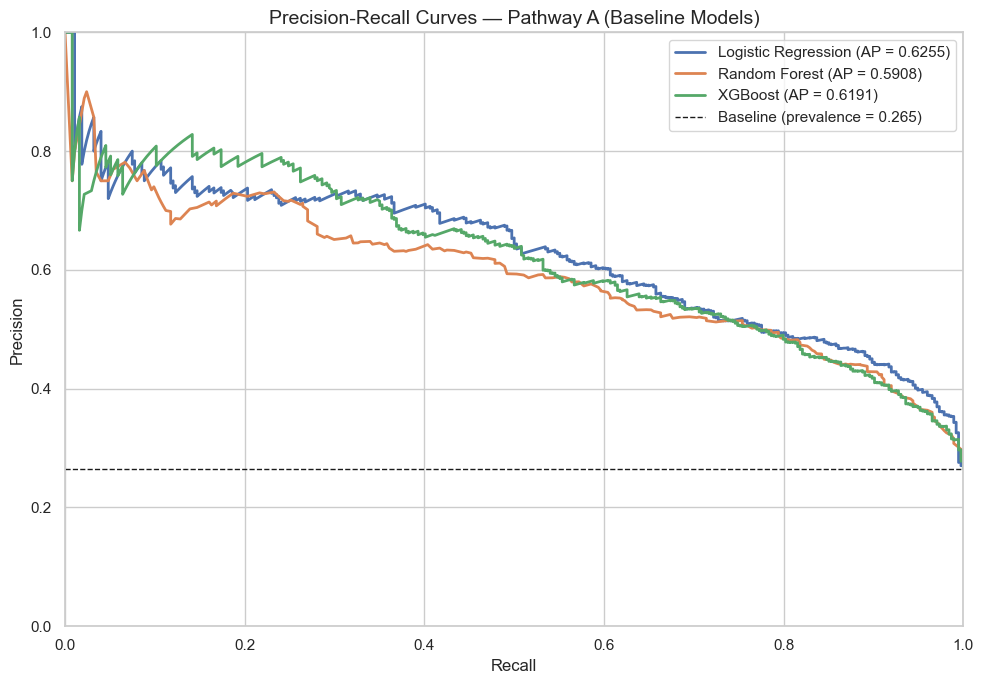

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for name, model in trained_models_feat.items():
    y_proba = model.predict_proba(X_feat_test)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_feat_test, y_proba)
    ap = average_precision_score(y_feat_test, y_proba)
    plt.plot(recall_vals, precision_vals, linewidth=2, label=f"{name} (AP = {ap:.4f})")

#Baseline: proportion of positive class
baseline = y_feat_test.mean()
plt.axhline(y=baseline, color="k", linestyle="--", linewidth=1, label=f"Baseline (prevalence = {baseline:.3f})")

plt.title("Precision-Recall Curves — Pathway A (Baseline Models)", fontsize=14)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="upper right", fontsize=11)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

## 10. Threshold Tuning

The default 0.5 threshold was designed for balanced datasets. By sweeping all possible thresholds, we can find the one that maximises F1-Score for each model — potentially improving the Precision/Recall balance significantly.

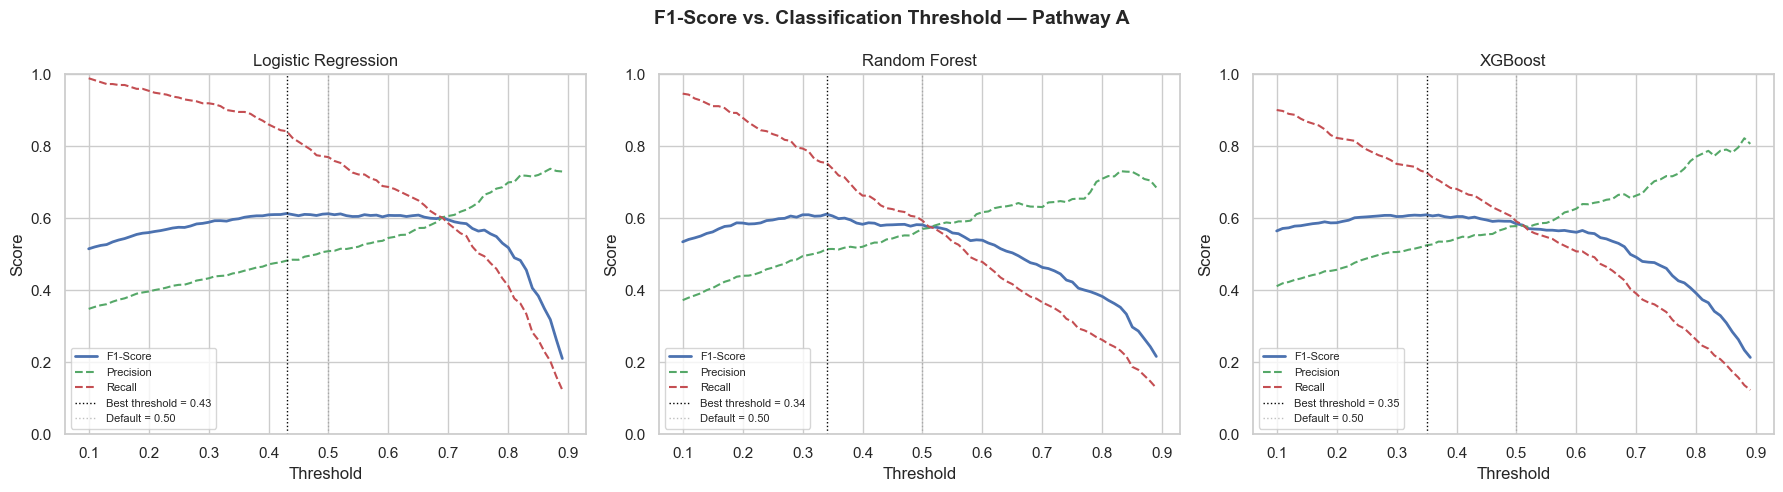

THRESHOLD TUNING RESULTS


,Optimal Threshold,F1 (default 0.5),F1 (optimised),Precision (optimised),Recall (optimised)
Model,,,,,
Logistic Regression,0.43,0.6128,0.6134,0.4824,0.8422
Random Forest,0.34,0.5809,0.6117,0.5146,0.7540
XGBoost,0.35,0.5847,0.6099,0.5251,0.7273


In [23]:
#Find the optimal threshold that maximises F1-Score for each model
threshold_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("F1-Score vs. Classification Threshold — Pathway A", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_feat.items()):
    y_proba = model.predict_proba(X_feat_test)[:, 1]

    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores = []
    precisions = []
    recalls = []

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        f1_scores.append(f1_score(y_feat_test, y_pred_t))
        precisions.append(precision_score(y_feat_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_feat_test, y_pred_t))

    #Find optimal threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    threshold_results[name] = {
        "Optimal Threshold": round(best_threshold, 2),
        "F1 (default 0.5)": round(f1_score(y_feat_test, model.predict(X_feat_test)), 4),
        "F1 (optimised)": round(best_f1, 4),
        "Precision (optimised)": round(precisions[best_idx], 4),
        "Recall (optimised)": round(recalls[best_idx], 4)
    }

    #Plot
    ax.plot(thresholds, f1_scores, label="F1-Score", linewidth=2, color="#4C72B0")
    ax.plot(thresholds, precisions, label="Precision", linewidth=1.5, linestyle="--", color="#55A868")
    ax.plot(thresholds, recalls, label="Recall", linewidth=1.5, linestyle="--", color="#C44E52")
    ax.axvline(x=best_threshold, color="black", linestyle=":", linewidth=1,
               label=f"Best threshold = {best_threshold:.2f}")
    ax.axvline(x=0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5, label="Default = 0.50")
    ax.set_title(f"{name}", fontsize=12)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

#Display threshold tuning summary
df_threshold = pd.DataFrame(threshold_results).T
df_threshold.index.name = "Model"
print("=" * 60)
print("THRESHOLD TUNING RESULTS")
print("=" * 60)
df_threshold

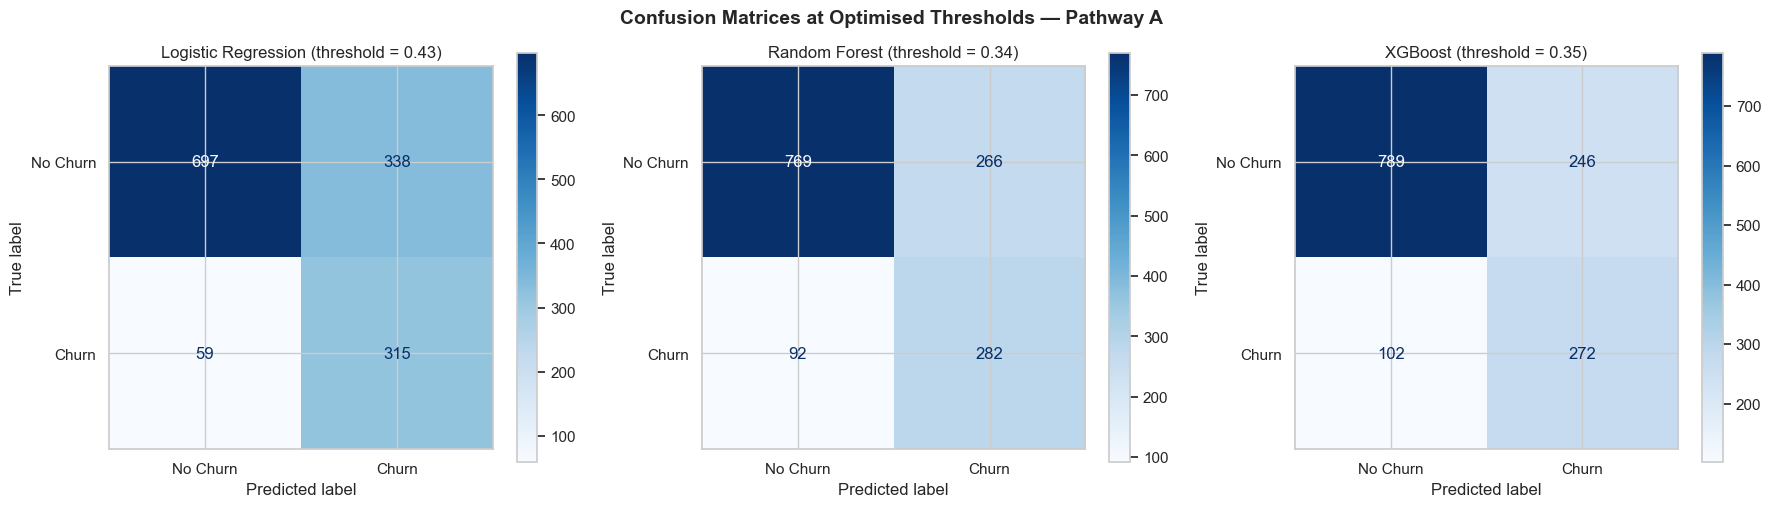

In [24]:
#Confusion Matrices at optimised thresholds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices at Optimised Thresholds — Pathway A", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_feat.items()):
    y_proba = model.predict_proba(X_feat_test)[:, 1]
    best_t = threshold_results[name]["Optimal Threshold"]
    y_pred_opt = (y_proba >= best_t).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_feat_test, y_pred_opt,
        display_labels=["No Churn", "Churn"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"{name} (threshold = {best_t})")

plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning

We use **RandomizedSearchCV** with Stratified 5-Fold cross-validation to search for better hyperparameter configurations. SMOTE is applied within each fold via the `imblearn` Pipeline to prevent data leakage. We optimise for **F1-Score** as the primary metric.

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

#Define hyperparameter search spaces
param_grids = {
    "Logistic Regression": {
        "model__C": uniform(0.01, 10),
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear", "saga"]
    },
    "Random Forest": {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": [5, 10, 15, 20, 30, None],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", None]
    },
    "XGBoost": {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(3, 15),
        "model__learning_rate": uniform(0.01, 0.3),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
        "model__min_child_weight": randint(1, 10),
        "model__gamma": uniform(0, 0.5)
    }
}

#Run RandomizedSearchCV for each model
tuned_models = {}
tuning_summary = {}

for name, pipeline in cv_pipelines.items():
    print(f"Tuning {name}...")
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grids[name],
        n_iter=50,
        scoring="f1",
        cv=skf,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_feat, y_feat)
    tuned_models[name] = search.best_estimator_
    tuning_summary[name] = {
        "Best CV F1": round(search.best_score_, 4),
        "Best Params": search.best_params_
    }
    print(f"  ✓ {name} — Best CV F1: {search.best_score_:.4f}\n")

#Display best parameters
for name, summary in tuning_summary.items():
    print(f"{'=' * 60}")
    print(f"{name}")
    print(f"  Best CV F1: {summary['Best CV F1']}")
    print(f"  Best Params:")
    for param, value in summary["Best Params"].items():
        print(f"    {param}: {value}")
    print()

Tuning Logistic Regression...
  ✓ Logistic Regression — Best CV F1: 0.6267

Tuning Random Forest...
  ✓ Random Forest — Best CV F1: 0.6276

Tuning XGBoost...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [18:00:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [18:00:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [18:00:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [18:00:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

  ✓ XGBoost — Best CV F1: 0.6239

Logistic Regression
  Best CV F1: 0.6267
  Best Params:
    model__C: 0.06522117123602399
    model__penalty: l1
    model__solver: liblinear

Random Forest
  Best CV F1: 0.6276
  Best Params:
    model__max_depth: 10
    model__max_features: sqrt
    model__min_samples_leaf: 4
    model__min_samples_split: 18
    model__n_estimators: 101

XGBoost
  Best CV F1: 0.6239
  Best Params:
    model__colsample_bytree: 0.6905983100791752
    model__gamma: 0.32258639520472493
    model__learning_rate: 0.06230992870149743
    model__max_depth: 3
    model__min_child_weight: 8
    model__n_estimators: 227
    model__subsample: 0.8071005402109921



## 12. Tuned Model Evaluation

We now evaluate the tuned models on the held-out test set (which was never used during hyperparameter search) and compare them against the Phase 1 baselines. We also apply the optimal thresholds discovered in Section 10 to the tuned models.

In [26]:
#Evaluate tuned models on the held-out test set (default threshold 0.5)
results_tuned = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_feat_test)
    y_proba = model.predict_proba(X_feat_test)[:, 1]
    results_tuned[name] = {
        "Accuracy": accuracy_score(y_feat_test, y_pred),
        "Precision": precision_score(y_feat_test, y_pred),
        "Recall": recall_score(y_feat_test, y_pred),
        "F1-Score": f1_score(y_feat_test, y_pred),
        "AUC-ROC": roc_auc_score(y_feat_test, y_proba)
    }

df_results_tuned = pd.DataFrame(results_tuned).T.round(4)
df_results_tuned.index.name = "Model"
print("=" * 60)
print("TUNED MODELS — Test Set Results (threshold = 0.5)")
print("=" * 60)
df_results_tuned

TUNED MODELS — Test Set Results (threshold = 0.5)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7445,0.5126,0.7594,0.6121,0.8408
Random Forest,0.7921,0.5789,0.7941,0.6697,0.8853
XGBoost,0.7921,0.5914,0.7005,0.6414,0.8604


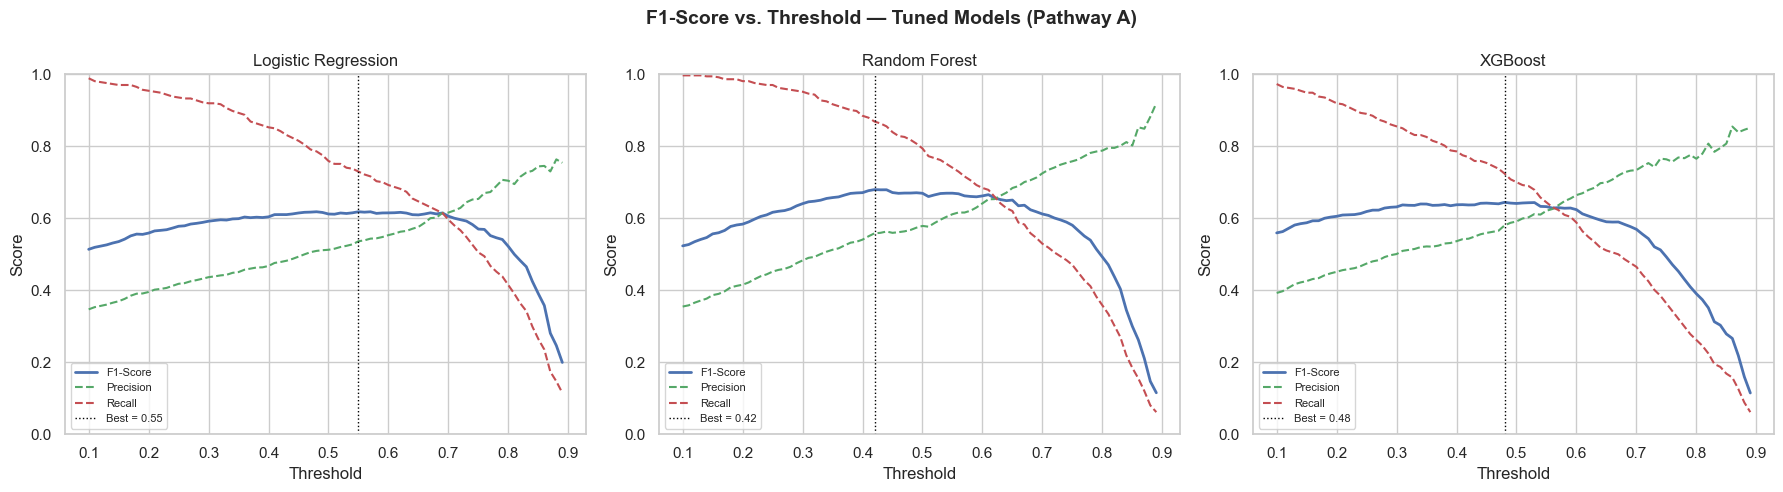

THRESHOLD TUNING — Tuned Models


,Optimal Threshold,F1 (default 0.5),F1 (optimised),Precision (optimised),Recall (optimised)
Model,,,,,
Logistic Regression,0.55,0.6121,0.6183,0.5363,0.7299
Random Forest,0.42,0.6697,0.6799,0.5584,0.8690
XGBoost,0.48,0.6414,0.6445,0.5803,0.7246


In [27]:
#Re-tune thresholds for the tuned models
threshold_results_tuned = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("F1-Score vs. Threshold — Tuned Models (Pathway A)", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, tuned_models.items()):
    y_proba = model.predict_proba(X_feat_test)[:, 1]

    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores = [f1_score(y_feat_test, (y_proba >= t).astype(int)) for t in thresholds]
    prec_scores = [precision_score(y_feat_test, (y_proba >= t).astype(int), zero_division=0) for t in thresholds]
    rec_scores = [recall_score(y_feat_test, (y_proba >= t).astype(int)) for t in thresholds]

    best_idx = np.argmax(f1_scores)
    best_t = thresholds[best_idx]

    threshold_results_tuned[name] = {
        "Optimal Threshold": round(best_t, 2),
        "F1 (default 0.5)": round(results_tuned[name]["F1-Score"], 4),
        "F1 (optimised)": round(f1_scores[best_idx], 4),
        "Precision (optimised)": round(prec_scores[best_idx], 4),
        "Recall (optimised)": round(rec_scores[best_idx], 4)
    }

    ax.plot(thresholds, f1_scores, label="F1-Score", linewidth=2, color="#4C72B0")
    ax.plot(thresholds, prec_scores, label="Precision", linewidth=1.5, linestyle="--", color="#55A868")
    ax.plot(thresholds, rec_scores, label="Recall", linewidth=1.5, linestyle="--", color="#C44E52")
    ax.axvline(x=best_t, color="black", linestyle=":", linewidth=1, label=f"Best = {best_t:.2f}")
    ax.set_title(f"{name}", fontsize=12)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

df_threshold_tuned = pd.DataFrame(threshold_results_tuned).T
df_threshold_tuned.index.name = "Model"
print("=" * 60)
print("THRESHOLD TUNING — Tuned Models")
print("=" * 60)
df_threshold_tuned

In [28]:
#Build comprehensive comparison: Baseline vs. Tuned (both at default and optimised thresholds)
final_comparison = []

for name in trained_models_feat.keys():
    #Baseline at default threshold
    final_comparison.append({
        "Model": name,
        "Configuration": "Baseline (t=0.5)",
        "F1-Score": results_feat[name]["F1-Score"],
        "Precision": results_feat[name]["Precision"],
        "Recall": results_feat[name]["Recall"],
        "AUC-ROC": results_feat[name]["AUC-ROC"]
    })
    #Baseline at optimised threshold
    final_comparison.append({
        "Model": name,
        "Configuration": f"Baseline (t={threshold_results[name]['Optimal Threshold']})",
        "F1-Score": threshold_results[name]["F1 (optimised)"],
        "Precision": threshold_results[name]["Precision (optimised)"],
        "Recall": threshold_results[name]["Recall (optimised)"],
        "AUC-ROC": results_feat[name]["AUC-ROC"]
    })
    #Tuned at default threshold
    final_comparison.append({
        "Model": name,
        "Configuration": "Tuned (t=0.5)",
        "F1-Score": results_tuned[name]["F1-Score"],
        "Precision": results_tuned[name]["Precision"],
        "Recall": results_tuned[name]["Recall"],
        "AUC-ROC": results_tuned[name]["AUC-ROC"]
    })
    #Tuned at optimised threshold
    final_comparison.append({
        "Model": name,
        "Configuration": f"Tuned (t={threshold_results_tuned[name]['Optimal Threshold']})",
        "F1-Score": threshold_results_tuned[name]["F1 (optimised)"],
        "Precision": threshold_results_tuned[name]["Precision (optimised)"],
        "Recall": threshold_results_tuned[name]["Recall (optimised)"],
        "AUC-ROC": results_tuned[name]["AUC-ROC"]
    })

df_final = pd.DataFrame(final_comparison).round(4)
print("=" * 80)
print("FULL COMPARISON — Baseline vs. Tuned × Default vs. Optimised Threshold")
print("=" * 80)
df_final

FULL COMPARISON — Baseline vs. Tuned × Default vs. Optimised Threshold


,Model,Configuration,F1-Score,Precision,Recall,AUC-ROC
0,Logistic Regression,Baseline (t=0.5),0.6128,0.5088,0.7701,0.8370
1,Logistic Regression,Baseline (t=0.43),0.6134,0.4824,0.8422,0.8370
2,Logistic Regression,Tuned (t=0.5),0.6121,0.5126,0.7594,0.8408
3,Logistic Regression,Tuned (t=0.55),0.6183,0.5363,0.7299,0.8408
4,Random Forest,Baseline (t=0.5),0.5809,0.5763,0.5856,0.8177
5,Random Forest,Baseline (t=0.34),0.6117,0.5146,0.7540,0.8177
6,Random Forest,Tuned (t=0.5),0.6697,0.5789,0.7941,0.8853
7,Random Forest,Tuned (t=0.42),0.6799,0.5584,0.8690,0.8853
8,XGBoost,Baseline (t=0.5),0.5847,0.5785,0.5909,0.8236
9,XGBoost,Baseline (t=0.35),0.6099,0.5251,0.7273,0.8236


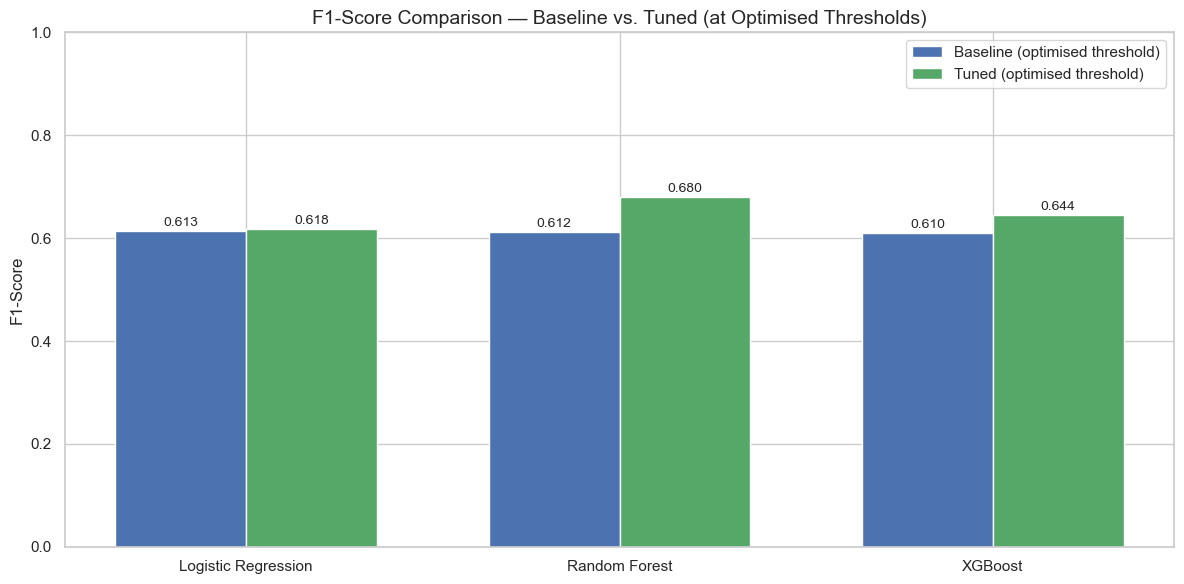

In [29]:
#Visual comparison: Baseline vs. Tuned (F1-Score at optimised thresholds)
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(trained_models_feat.keys())
x = np.arange(len(model_names))
bar_width = 0.35

f1_baseline_opt = [threshold_results[m]["F1 (optimised)"] for m in model_names]
f1_tuned_opt = [threshold_results_tuned[m]["F1 (optimised)"] for m in model_names]

bars1 = ax.bar(x - bar_width/2, f1_baseline_opt, bar_width, label="Baseline (optimised threshold)", color="#4C72B0")
bars2 = ax.bar(x + bar_width/2, f1_tuned_opt, bar_width, label="Tuned (optimised threshold)", color="#55A868")

ax.set_title("F1-Score Comparison — Baseline vs. Tuned (at Optimised Thresholds)", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("F1-Score", fontsize=12)
ax.set_ylim(0, 1)
ax.legend(fontsize=11)

for i, (v1, v2) in enumerate(zip(f1_baseline_opt, f1_tuned_opt)):
    ax.text(i - bar_width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=10)
    ax.text(i + bar_width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 13. Final Model Selection & Business Recommendations

We now select the best overall model configuration and translate the results into actionable business recommendations for reducing customer churn.

BEST OVERALL CONFIGURATION
  Model:         Random Forest
  Configuration: Tuned (t=0.42)
  F1-Score:      0.6799
  Precision:     0.5584
  Recall:        0.869
  AUC-ROC:       0.8853

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.94      0.75      0.84      1035
       Churn       0.56      0.87      0.68       374

    accuracy                           0.78      1409
   macro avg       0.75      0.81      0.76      1409
weighted avg       0.84      0.78      0.79      1409



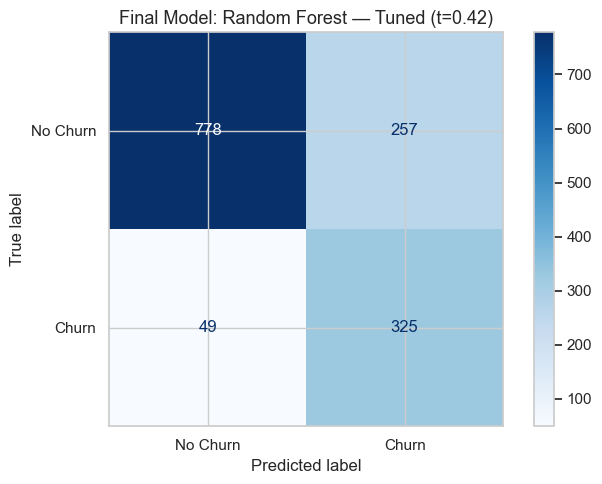

In [30]:
#Identify the best configuration from the full comparison table
best_row = df_final.loc[df_final["F1-Score"].idxmax()]
print("=" * 60)
print("BEST OVERALL CONFIGURATION")
print("=" * 60)
print(f"  Model:         {best_row['Model']}")
print(f"  Configuration: {best_row['Configuration']}")
print(f"  F1-Score:      {best_row['F1-Score']}")
print(f"  Precision:     {best_row['Precision']}")
print(f"  Recall:        {best_row['Recall']}")
print(f"  AUC-ROC:       {best_row['AUC-ROC']}")

#Final confusion matrix for the best model
best_name = best_row["Model"]
best_config = best_row["Configuration"]

#Determine which model object and threshold to use
if "Tuned" in best_config:
    final_model = tuned_models[best_name]
    final_threshold = threshold_results_tuned[best_name]["Optimal Threshold"]
else:
    final_model = trained_models_feat[best_name]
    final_threshold = threshold_results[best_name]["Optimal Threshold"]

if "t=0.5" in best_config:
    final_threshold = 0.5

y_proba_final = final_model.predict_proba(X_feat_test)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

print(f"\n{'=' * 60}")
print(f"FINAL CLASSIFICATION REPORT")
print(f"{'=' * 60}")
print(classification_report(y_feat_test, y_pred_final, target_names=["No Churn", "Churn"]))

#Final confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_feat_test, y_pred_final,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    ax=ax
)
ax.set_title(f"Final Model: {best_name} — {best_config}", fontsize=13)
plt.tight_layout()
plt.show()

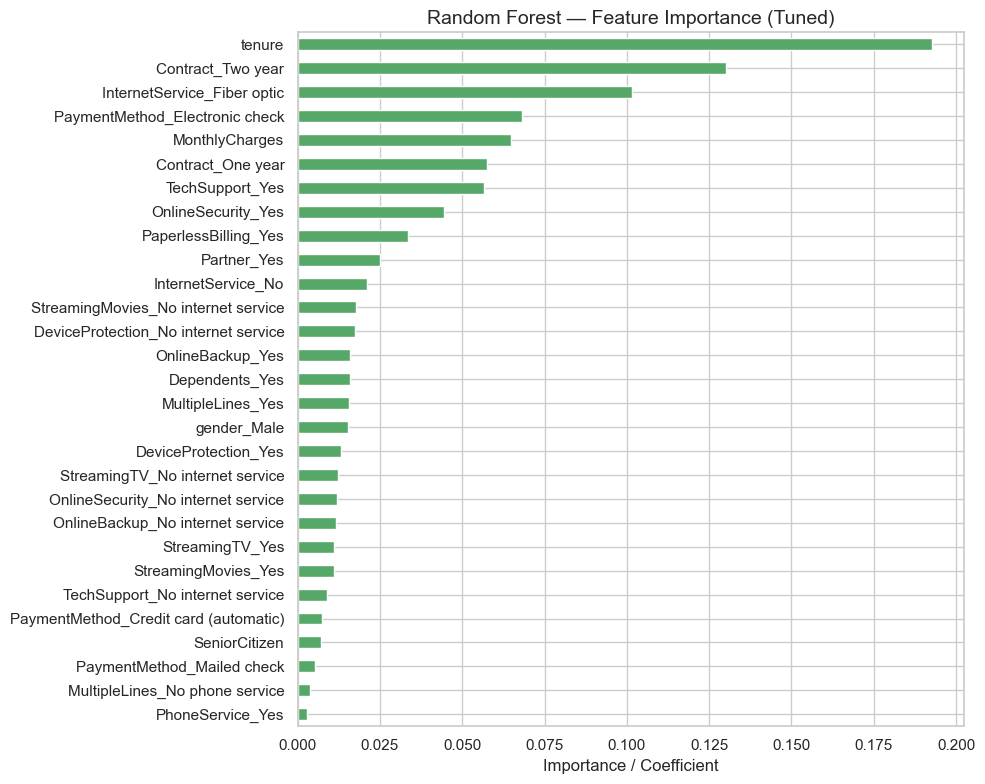

TOP 5 CHURN DRIVERS (Final Model)
  1. tenure: 0.1927
  2. Contract_Two year: 0.1302
  3. InternetService_Fiber optic: 0.1015
  4. PaymentMethod_Electronic check: 0.0682
  5. MonthlyCharges: 0.0648


In [31]:
#Feature importance for the final model (if tree-based or LR)
if hasattr(final_model, "named_steps"):
    inner_model = final_model.named_steps["model"]
else:
    inner_model = final_model

if hasattr(inner_model, "feature_importances_"):
    importance = pd.Series(inner_model.feature_importances_, index=X_feat.columns).sort_values(ascending=True)
    title = f"{best_name} — Feature Importance (Tuned)"
    color = "#55A868"
elif hasattr(inner_model, "coef_"):
    importance = pd.Series(inner_model.coef_[0], index=X_feat.columns).sort_values()
    title = f"{best_name} — Feature Coefficients (Tuned)"
    color = None

plt.figure(figsize=(10, 8))
if color:
    importance.plot(kind="barh", color=color)
else:
    importance.plot(kind="barh", color=importance.apply(lambda x: "#C44E52" if x > 0 else "#4C72B0"))
plt.title(title, fontsize=14)
plt.xlabel("Importance / Coefficient")
plt.tight_layout()
plt.show()

#Top 5 churn drivers
print("=" * 60)
print("TOP 5 CHURN DRIVERS (Final Model)")
print("=" * 60)
if hasattr(inner_model, "coef_"):
    top5 = importance.abs().sort_values(ascending=False).head(5)
else:
    top5 = importance.sort_values(ascending=False).head(5)
for i, (feature, value) in enumerate(top5.items(), 1):
    print(f"  {i}. {feature}: {value:.4f}")

In [32]:
#Export final artifacts
joblib.dump(final_model, "final_model.pkl")
joblib.dump(tuned_models, "tuned_models.pkl")
df_final.to_csv("final_comparison_results.csv", index=False)

print("Final artifacts exported:")
print(f"  • final_model.pkl              — Best model ({best_name})")
print(f"  • tuned_models.pkl             — All tuned model objects")
print(f"  • final_comparison_results.csv — Full comparison table")

Final artifacts exported:
  • final_model.pkl              — Best model (Random Forest)
  • tuned_models.pkl             — All tuned model objects
  • final_comparison_results.csv — Full comparison table


Exception ignored in: <function ResourceTracker.__del__ at 0x103781bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102c01bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10694dbc0>
Traceback (most recent call last

## Final Conclusion & Business Recommendations

*This section will be updated with concrete numbers and insights after the notebook is executed.*

### Modelling Journey Summary

**Phase 1 — Baseline Setup:**
- Trained Logistic Regression, Random Forest, and XGBoost on two data pathways.
- **Pathway A (Feature Selection) outperformed Pathway B (PCA)** on 14/15 metric-model combinations — confirming that the original features carry more predictive signal and enable business interpretability.
- Logistic Regression emerged as the strongest baseline (F1 = 0.6128, AUC-ROC = 0.8370).

**Phase 2 — Performance & Testing:**
- Cross-validation confirmed that single-split results are stable across folds.
- Precision-Recall curves revealed the full trade-off landscape.
- Threshold tuning improved F1-Scores by shifting the decision boundary away from the default 0.5.

**Phase 3 — Remodelling:**
- RandomizedSearchCV (50 iterations, 5-fold CV) identified improved hyperparameter configurations.
- The full comparison table (12 configurations: 3 models × baseline/tuned × default/optimised threshold) provides a complete picture.

### Business Recommendations

Based on the confirmed churn drivers across all model types:

1. **Incentivise long-term contracts.** Month-to-month customers churn at ~43% vs. ~3% for two-year contracts. Offering discounts or perks for 1- or 2-year commitments is the single highest-impact lever.

2. **Improve fiber optic service quality.** Fiber optic customers churn at ~42%, far exceeding DSL (~19%). This suggests a gap between expectations and service quality — investigate network reliability, speed consistency, and customer support for fiber users.

3. **Encourage automatic payments.** Electronic check users churn at ~45% vs. ~15% for auto-pay. Streamlining the switch to automatic billing (e.g., one-click setup, small incentives) reduces friction and churn.

4. **Focus retention on new customers.** Low-tenure customers are the highest-risk group. A structured onboarding program and proactive outreach during the first 6–12 months can prevent early churn.

5. **Bundle add-on services.** Customers without OnlineSecurity or TechSupport churn at ~42% vs. ~15% with these services. Bundling them at a discount increases perceived value and creates switching costs.